# Predicción del Valor de Mercado de Jugadores de Fútbol

**Instituto Tecnológico de Buenos Aires (ITBA)**  
**Materia:** Ciencia de Datos  
**Dataset:** Football Data from Transfermarkt (Kaggle)  

---

## Objetivo del Proyecto

Este proyecto busca predecir el **valor de mercado** de jugadores de fútbol profesional utilizando datos históricos de rendimiento, apariciones en partidos, transferencias y características personales. El valor de mercado es un indicador clave usado por clubes, agentes y medios para evaluar el potencial económico de un jugador.

## Estructura del Notebook

1. Instalación e importación de librerías  
2. Montaje de Google Drive y carga de datos  
3. Descripción del dataset  
4. Análisis Exploratorio de Datos (EDA)  
5. Visualizaciones  
6. Diagnóstico de calidad de datos  
7. Transformaciones  
8. Feature Engineering — Variables Adicionales  
9. Reflexión final  

## 1. Instalación e Importación de Librerías

In [ ]:
# Instalación de librerías adicionales si es necesario (en Colab suelen estar preinstaladas)
!pip install -q seaborn --upgrade

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configuración visual global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

print('Librerías cargadas correctamente.')
print(f'pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}')

Librerías cargadas correctamente.
pandas 2.2.2 | numpy 2.0.2 | seaborn 0.13.2


## 2. Montaje de Google Drive y Carga de Datos

Los archivos CSV deben estar en la carpeta `futbol-valuacion/data/raw/` dentro de tu Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Ajustá este path si tu carpeta tiene otro nombre o ubicación
DATA_PATH = '/content/drive/MyDrive/futbol-valuacion/data/raw/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Carga de las 4 tablas principales
players      = pd.read_csv(DATA_PATH + 'players.csv')
appearances  = pd.read_csv(DATA_PATH + 'appearances.csv')
valuations   = pd.read_csv(DATA_PATH + 'player_valuations.csv')
transfers    = pd.read_csv(DATA_PATH + 'transfers.csv')

print('Tablas cargadas:')
for nombre, df in [('players', players), ('appearances', appearances),
                   ('player_valuations', valuations), ('transfers', transfers)]:
    print(f'  {nombre}: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Tablas cargadas:
  players: 47,702 filas x 26 columnas
  appearances: 1,862,208 filas x 13 columnas
  player_valuations: 616,377 filas x 6 columnas
  transfers: 157,186 filas x 10 columnas


## 3. Descripción del Dataset

### Origen
Los datos provienen de **Transfermarkt**, el sitio de referencia mundial para valuaciones de jugadores de fútbol. El dataset fue publicado en Kaggle bajo el nombre *"Football Data from Transfermarkt"* y contiene información de ligas europeas de primer nivel.

### Tablas utilizadas

| Tabla | Descripción | Variables clave |
|---|---|---|
| `players` | Perfil de cada jugador | `player_id`, `name`, `position`, `date_of_birth`, `market_value_in_eur` |
| `appearances` | Estadísticas por partido | `player_id`, `game_id`, `goals`, `assists`, `minutes_played` |
| `player_valuations` | Historial de valuaciones | `player_id`, `date`, `market_value_in_eur` |
| `transfers` | Historial de transferencias | `player_id`, `transfer_fee`, `from_club_id`, `to_club_id` |

### Justificación
El valor de mercado depende de múltiples factores: edad, posición, rendimiento reciente, historial de transferencias y liga donde juega. Estas tablas capturan esas dimensiones y permiten construir features predictivas ricas.

## 4. Análisis Exploratorio Básico

In [ ]:
# ── players ──────────────────────────────────────────────
print('=== players ===')
print(f'Shape: {players.shape}')
print(f'\nTipos de variables:')
print(players.dtypes)
players.head(3)

=== players ===
Shape: (47702, 26)

Tipos de variables:
player_id                                 int64
first_name                               object
last_name                                object
name                                     object
last_season                               int64
current_club_id                           int64
player_code                              object
country_of_birth                         object
city_of_birth                            object
country_of_citizenship                   object
date_of_birth                            object
sub_position                             object
position                                 object
foot                                     object
height_in_cm                            float64
contract_expiration_date                 object
agent_name                               object
image_url                                object
international_caps                      float64
international_goals             

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0


In [ ]:
# Estadísticas descriptivas de players
players.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
player_id,47702.0,NaN,NaN,NaN,485087.298247,368533.876999,10.0,176852.5,401355.5,727015.25,1529719.0
first_name,44607,10300,David,322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_name,47702,32482,Kim,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,47702,46449,Paulinho,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_season,47702.0,NaN,NaN,NaN,2021.446208,4.260824,2012.0,2018.0,2024.0,2025.0,2025.0
current_club_id,47702.0,NaN,NaN,NaN,8217.525659,16880.99213,2.0,504.0,1465.0,6676.0,138189.0
player_code,47702,46367,joao-pedro,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_of_birth,42540,203,France,2598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_of_birth,42815,11651,London,539,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_of_citizenship,47431,198,Brazil,2683,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Valores faltantes en players
nulos = players.isnull().sum()
nulos_pct = (nulos / len(players) * 100).round(2)
pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct}).query('Nulos > 0').sort_values('Porcentaje (%)', ascending=False)

,Nulos,Porcentaje (%)
current_national_team_id,44611,93.52
international_goals,29979,62.85
international_caps,29979,62.85
agent_name,22180,46.50
contract_expiration_date,16488,34.56
market_value_in_eur,8476,17.77
highest_market_value_in_eur,8476,17.77
foot,5256,11.02
country_of_birth,5162,10.82
city_of_birth,4887,10.24


In [ ]:
# Duplicados en cada tabla
for nombre, df in [('players', players), ('appearances', appearances),
                   ('player_valuations', valuations), ('transfers', transfers)]:
    dupes = df.duplicated().sum()
    print(f'{nombre}: {dupes} filas duplicadas ({dupes/len(df)*100:.2f}%)')

players: 0 filas duplicadas (0.00%)
appearances: 0 filas duplicadas (0.00%)
player_valuations: 0 filas duplicadas (0.00%)
transfers: 0 filas duplicadas (0.00%)


In [ ]:
# ── appearances ──────────────────────────────────────────
print('=== appearances ===')
print(f'Shape: {appearances.shape}')
display(appearances.head(3))
display(appearances.describe())

=== appearances ===
Shape: (1862208, 13)


,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2231978_38004,2231978,38004,853,235,2012-07-03,Aurélien Joachim,CLQ,0,0,2,0,90
1,2233748_79232,2233748,79232,8841,2698,2012-07-05,Ruslan Abyshov,ELQ,0,0,0,0,90
2,2234413_42792,2234413,42792,6251,465,2012-07-05,Sander Puri,ELQ,0,0,0,0,45


,game_id,player_id,player_club_id,player_current_club_id,yellow_cards,red_cards,goals,assists,minutes_played
count,1.862208e+06,1.862208e+06,1.862208e+06,1.862208e+06,1.862208e+06,1.862208e+06,1.862208e+06,1.862208e+06,1.862208e+06
mean,3.286325e+06,2.356550e+05,3.315381e+03,5.345555e+03,1.457914e-01,3.790661e-03,9.544208e-02,7.510654e-02,6.863815e+01
std,7.518454e+05,2.197747e+05,9.091648e+03,1.357689e+04,3.636764e-01,6.145156e-02,3.299035e-01,2.847677e-01,3.015031e+01
min,2.211607e+06,1.000000e+01,1.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,2.606535e+06,6.165100e+04,2.890000e+02,3.670000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.500000e+01
50%,3.203656e+06,1.707670e+05,8.250000e+02,9.870000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+01
75%,3.886492e+06,3.424050e+05,2.439000e+03,3.060000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+01
max,4.839901e+06,1.510255e+06,1.328770e+05,1.381890e+05,2.000000e+00,1.000000e+00,6.000000e+00,6.000000e+00,1.480000e+02


In [ ]:
# ── player_valuations ────────────────────────────────────
print('=== player_valuations ===')
print(f'Shape: {valuations.shape}')
display(valuations.head(3))

# Convertir fecha
valuations['date'] = pd.to_datetime(valuations['date'])
print(f'\nRango temporal: {valuations["date"].min().date()} → {valuations["date"].max().date()}')

=== player_valuations ===
Shape: (616377, 6)


,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,Unknown,3057.0,BE1
1,342216,2001-07-20,100000,Unknown,1241.0,SC1
2,3132,2003-12-09,400000,Dynamo Kyiv,126.0,TR1



Rango temporal: 2000-01-20 → 2026-03-30


In [ ]:
# ── transfers ────────────────────────────────────────────
print('=== transfers ===')
print(f'Shape: {transfers.shape}')
display(transfers.head(3))
display(transfers.describe())

=== transfers ===
Shape: (157186, 10)


,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name
0,467994,2030-06-30,25/26,5621,749,Reggiana,FC Empoli,0.0,700000.0,Luca Belardinelli
1,784335,2027-07-18,27/28,6505,6502,Gimcheon Sangmu,Jeonbuk Hyundai,0.0,500000.0,Jun-soo Byeon
2,402135,2027-07-04,27/28,6505,515,Gimcheon Sangmu,Without Club,NaN,350000.0,Jun-su Ahn


,player_id,from_club_id,to_club_id,transfer_fee,market_value_in_eur
count,1.571860e+05,157186.000000,157186.000000,1.023530e+05,9.633800e+04
mean,5.021871e+05,20156.261461,15612.525040,8.023499e+05,1.882969e+06
std,3.128459e+05,27177.836622,23659.217653,4.441027e+06,4.913449e+06
min,3.333000e+03,1.000000,1.000000,0.000000e+00,1.000000e+04
25%,2.540030e+05,1047.000000,800.000000,0.000000e+00,2.000000e+05
50%,4.488135e+05,8817.000000,4961.000000,0.000000e+00,5.000000e+05
75%,6.982352e+05,28870.000000,18852.000000,0.000000e+00,1.500000e+06
max,1.529719e+06,140641.000000,140573.000000,2.220000e+08,1.800000e+08


## 5. Visualizaciones

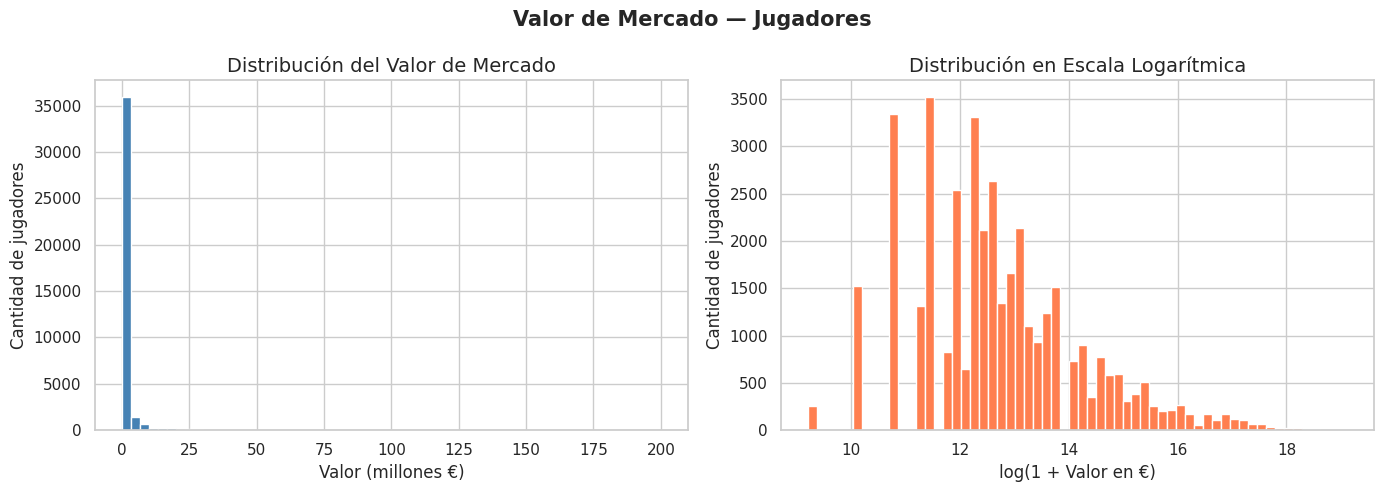

Mediana: €0.28M | Media: €1.56M | Máximo: €200M


In [ ]:
# Distribución del valor de mercado actual (players)
mv = players['market_value_in_eur'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala original
axes[0].hist(mv / 1e6, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del Valor de Mercado')
axes[0].set_xlabel('Valor (millones €)')
axes[0].set_ylabel('Cantidad de jugadores')

# Escala logarítmica
axes[1].hist(np.log1p(mv), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Distribución en Escala Logarítmica')
axes[1].set_xlabel('log(1 + Valor en €)')
axes[1].set_ylabel('Cantidad de jugadores')

plt.suptitle('Valor de Mercado — Jugadores', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mediana: €{mv.median()/1e6:.2f}M | Media: €{mv.mean()/1e6:.2f}M | Máximo: €{mv.max()/1e6:.0f}M')

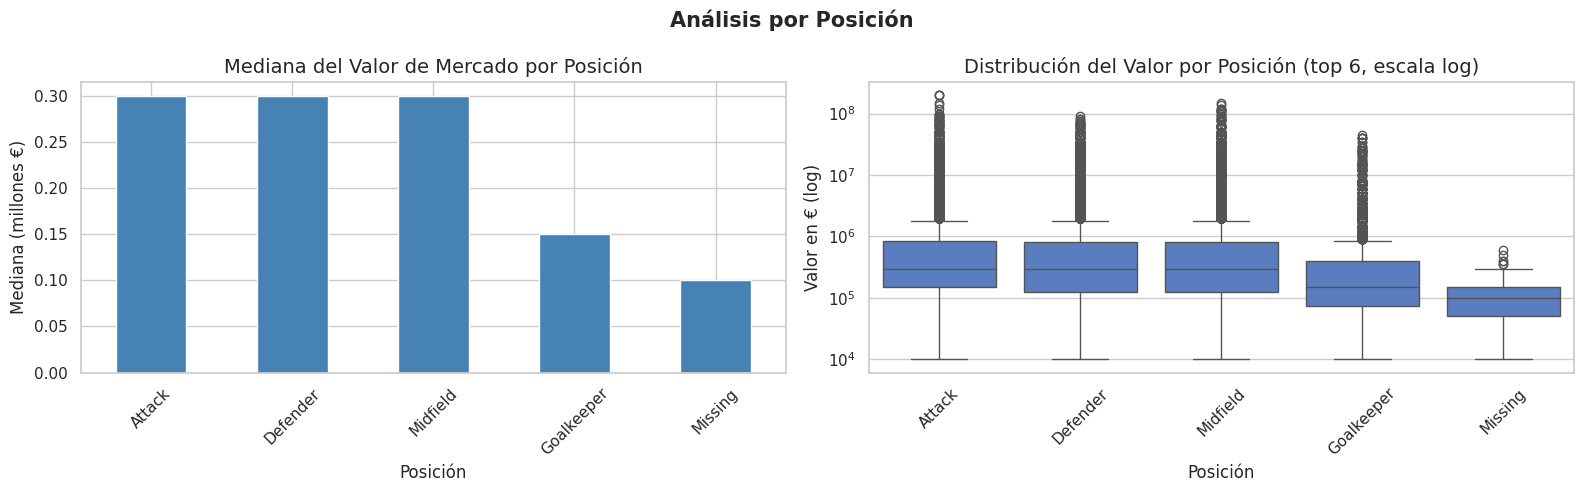

In [ ]:
# Valor de mercado por posición
pos_col = 'position' if 'position' in players.columns else 'sub_position'

valor_por_posicion = (
    players.dropna(subset=[pos_col, 'market_value_in_eur'])
    .groupby(pos_col)['market_value_in_eur']
    .median()
    .sort_values(ascending=False)
    / 1e6
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot mediana por posición
valor_por_posicion.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Mediana del Valor de Mercado por Posición')
axes[0].set_xlabel('Posición')
axes[0].set_ylabel('Mediana (millones €)')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot distribución por posición
top_pos = valor_por_posicion.head(6).index.tolist()
df_box = players[players[pos_col].isin(top_pos)].dropna(subset=['market_value_in_eur'])
sns.boxplot(data=df_box, x=pos_col, y='market_value_in_eur', order=top_pos, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Distribución del Valor por Posición (top 6, escala log)')
axes[1].set_xlabel('Posición')
axes[1].set_ylabel('Valor en € (log)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Análisis por Posición', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

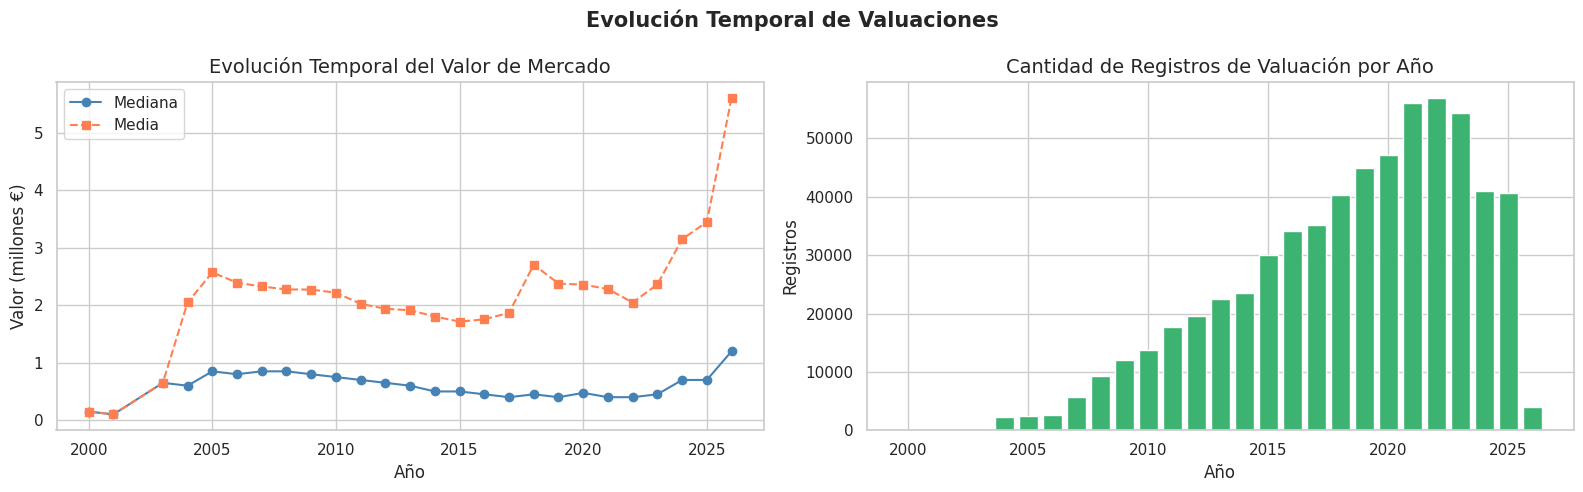

In [ ]:
# Evolución temporal de valuaciones
valuations['year'] = valuations['date'].dt.year

evolucion = (
    valuations.groupby('year')['market_value_in_eur']
    .agg(['median', 'mean', 'count'])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(evolucion['year'], evolucion['median'] / 1e6, marker='o', label='Mediana', color='steelblue')
axes[0].plot(evolucion['year'], evolucion['mean'] / 1e6, marker='s', label='Media', color='coral', linestyle='--')
axes[0].set_title('Evolución Temporal del Valor de Mercado')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Valor (millones €)')
axes[0].legend()

axes[1].bar(evolucion['year'], evolucion['count'], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Cantidad de Registros de Valuación por Año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Registros')

plt.suptitle('Evolución Temporal de Valuaciones', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

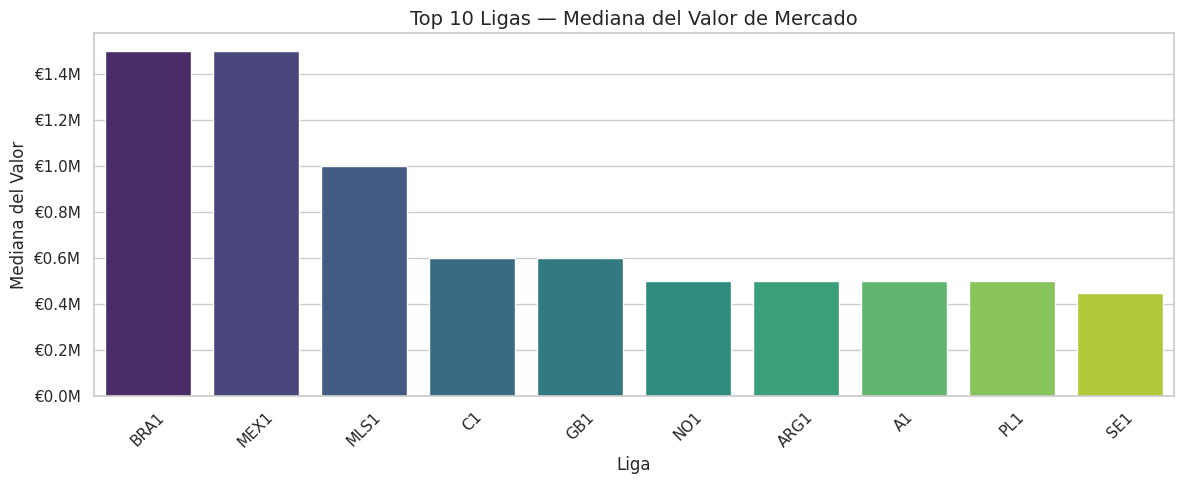

In [ ]:
# Top ligas por valor mediano de jugadores
liga_col = None
for col in ['current_club_domestic_competition_id', 'league_id', 'competition_id']:
    if col in players.columns:
        liga_col = col
        break

if liga_col:
    top_ligas = (
        players.dropna(subset=[liga_col, 'market_value_in_eur'])
        .groupby(liga_col)['market_value_in_eur']
        .agg(['median', 'count'])
        .query('count >= 50')
        .sort_values('median', ascending=False)
        .head(10)
        / 1e6
    )
    # Corregir la división que afectó 'count'
    top_ligas = (
        players.dropna(subset=[liga_col, 'market_value_in_eur'])
        .groupby(liga_col)['market_value_in_eur']
        .agg(mediana='median', cantidad='count')
        .query('cantidad >= 50')
        .sort_values('mediana', ascending=False)
        .head(10)
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=top_ligas.reset_index(), x=liga_col, y='mediana', ax=ax, palette='viridis')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1e6:.1f}M'))
    ax.set_title('Top 10 Ligas — Mediana del Valor de Mercado')
    ax.set_xlabel('Liga')
    ax.set_ylabel('Mediana del Valor')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No se encontró columna de liga en players. Verificar el CSV.')

## 6. Diagnóstico de Calidad de Datos

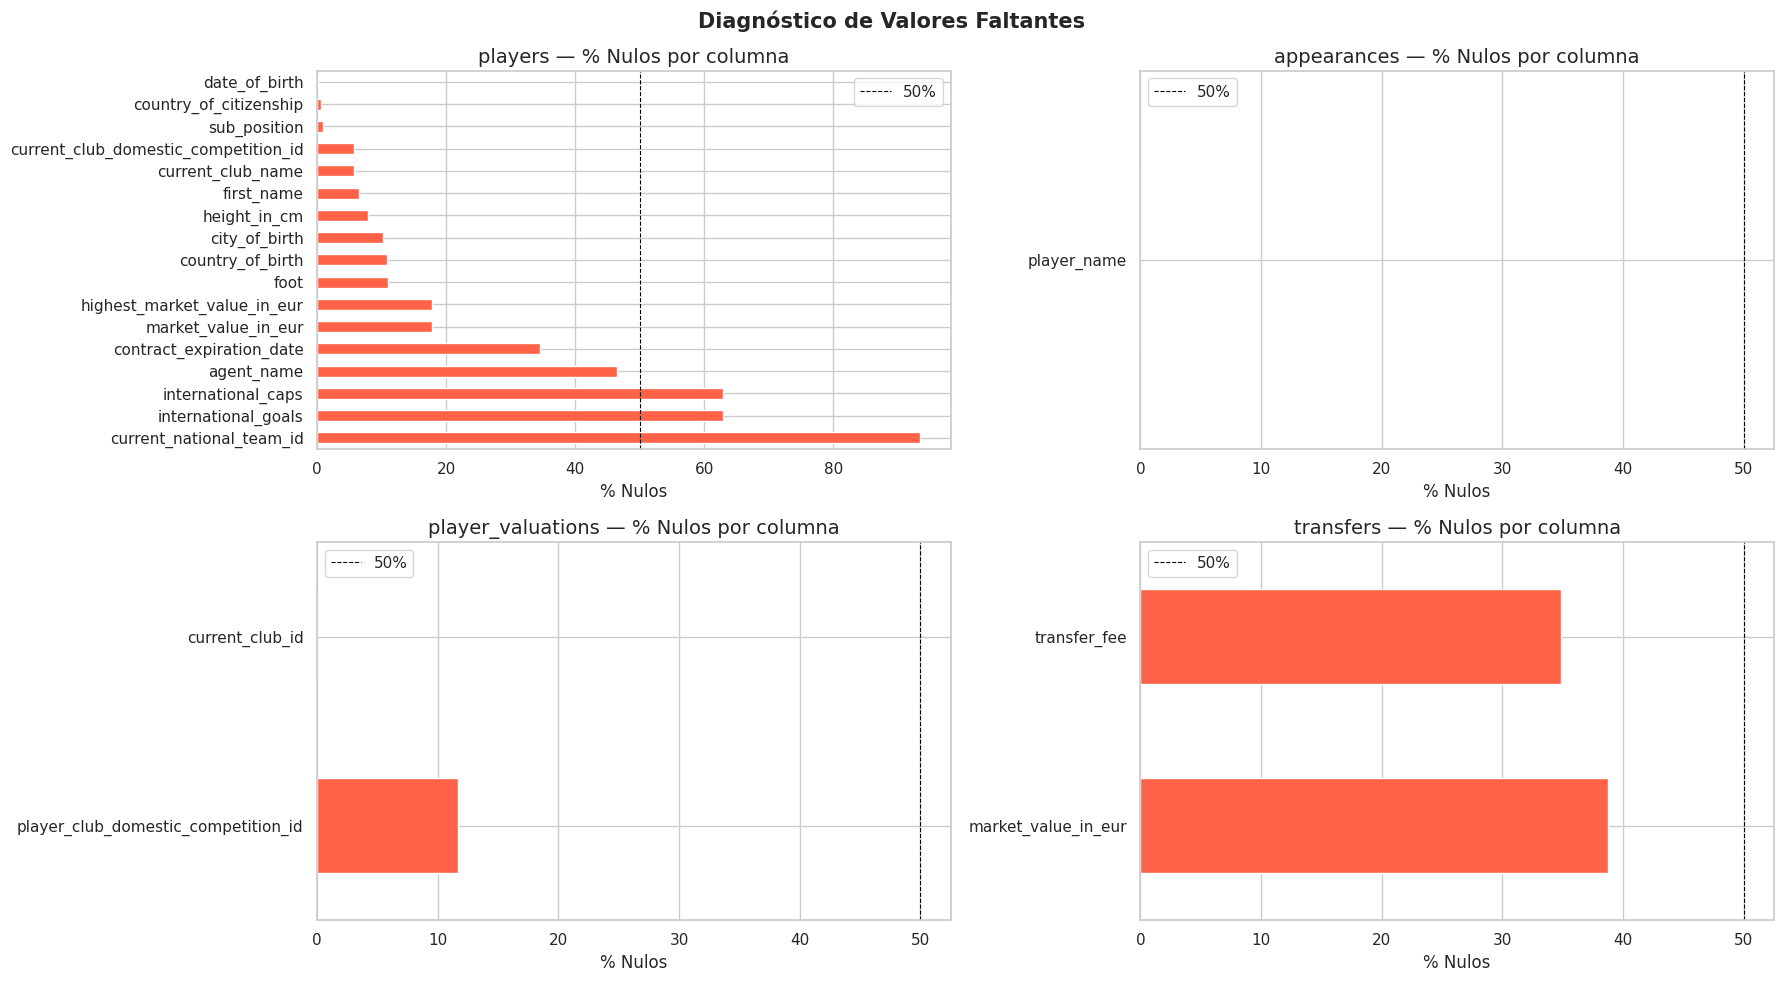

In [ ]:
# Mapa de nulos por tabla
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for ax, (nombre, df) in zip(axes.flatten(),
    [('players', players), ('appearances', appearances),
     ('player_valuations', valuations), ('transfers', transfers)]):

    nulos_pct = df.isnull().mean() * 100
    nulos_pct = nulos_pct[nulos_pct > 0].sort_values(ascending=False)

    if nulos_pct.empty:
        ax.text(0.5, 0.5, 'Sin valores nulos', ha='center', va='center', fontsize=13)
        ax.set_title(nombre)
    else:
        nulos_pct.plot(kind='barh', ax=ax, color='tomato', edgecolor='white')
        ax.set_title(f'{nombre} — % Nulos por columna')
        ax.set_xlabel('% Nulos')
        ax.axvline(50, color='black', linestyle='--', linewidth=0.8, label='50%')
        ax.legend()

plt.suptitle('Diagnóstico de Valores Faltantes', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Outliers en valor de mercado — método IQR
mv = players['market_value_in_eur'].dropna()
Q1, Q3 = mv.quantile(0.25), mv.quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = mv[mv > limite_superior]
print(f'Límite IQR superior: €{limite_superior/1e6:.2f}M')
print(f'Outliers detectados: {len(outliers)} ({len(outliers)/len(mv)*100:.1f}% del total)')
print(f'\nTop 10 jugadores por valor de mercado:')

top10 = (
    players[['name', 'market_value_in_eur', 'position']]
    .dropna(subset=['market_value_in_eur'])
    .sort_values('market_value_in_eur', ascending=False)
    .head(10)
)
top10['market_value_in_eur'] = top10['market_value_in_eur'].apply(lambda x: f'€{x/1e6:.1f}M')
display(top10)

Límite IQR superior: €1.73M
Outliers detectados: 5566 (14.2% del total)

Top 10 jugadores por valor de mercado:


,name,market_value_in_eur,position
40538,Lamine Yamal,€200.0M,Attack
20835,Kylian Mbappé,€200.0M,Attack
24550,Erling Haaland,€200.0M,Attack
22408,Vinicius Junior,€150.0M,Attack
34346,Pedri,€150.0M,Midfield
30618,Jude Bellingham,€140.0M,Midfield
30009,Michael Olise,€140.0M,Attack
21775,Declan Rice,€120.0M,Midfield
30556,Jamal Musiala,€120.0M,Midfield
22238,Federico Valverde,€120.0M,Midfield


In [ ]:
# Inconsistencias: jugadores sin apariciones registradas
jugadores_con_apariciones = appearances['player_id'].nunique()
jugadores_total = players['player_id'].nunique()
sin_apariciones = jugadores_total - jugadores_con_apariciones

print(f'Jugadores únicos en players: {jugadores_total:,}')
print(f'Jugadores con al menos una aparición: {jugadores_con_apariciones:,}')
print(f'Jugadores SIN apariciones registradas: {sin_apariciones:,} ({sin_apariciones/jugadores_total*100:.1f}%)')

# Inconsistencias: valuaciones sin match en players
ids_sin_match = set(valuations['player_id']) - set(players['player_id'])
print(f'\nIDs en valuations sin match en players: {len(ids_sin_match):,}')

# Verificar valores negativos en transfers
if 'transfer_fee' in transfers.columns:
    negativos = (transfers['transfer_fee'] < 0).sum()
    print(f'Transferencias con fee negativo: {negativos}')

Jugadores únicos en players: 47,702
Jugadores con al menos una aparición: 28,665
Jugadores SIN apariciones registradas: 19,037 (39.9%)

IDs en valuations sin match en players: 135
Transferencias con fee negativo: 0


## 7. Transformaciones

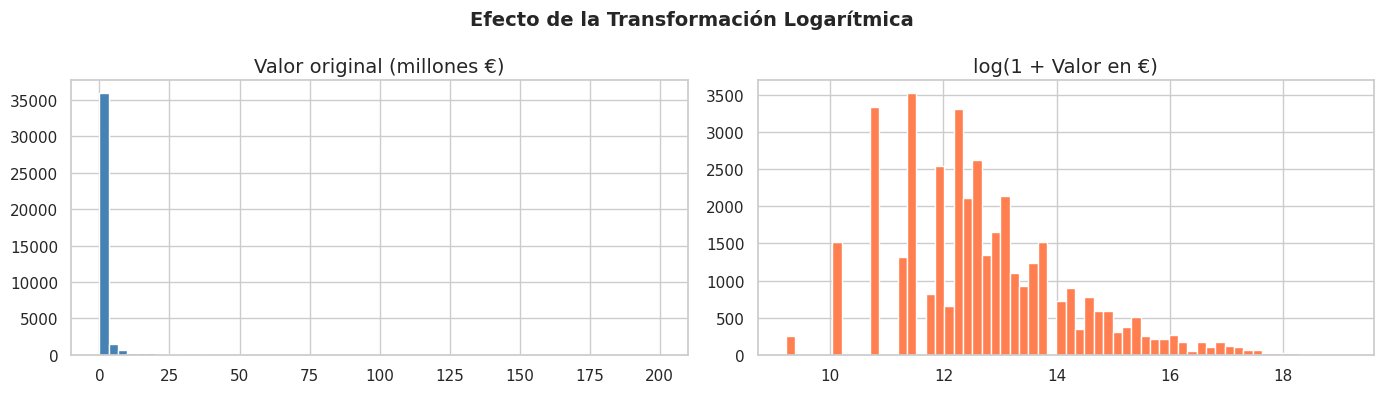

Skewness original: 11.60
Skewness log:      0.68


In [ ]:
# Transformación logarítmica del target (market_value_in_eur)
# La distribución original es muy sesgada a la derecha; log la normaliza
players['log_market_value'] = np.log1p(players['market_value_in_eur'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(players['market_value_in_eur'].dropna() / 1e6, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Valor original (millones €)')
axes[1].hist(players['log_market_value'].dropna(), bins=60, color='coral', edgecolor='white')
axes[1].set_title('log(1 + Valor en €)')
plt.suptitle('Efecto de la Transformación Logarítmica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness original: {players["market_value_in_eur"].skew():.2f}')
print(f'Skewness log:      {players["log_market_value"].skew():.2f}')

In [ ]:
# Encoding de posición — mapeo ordinal basado en zona del campo
# Esta es una aproximación; en modelado se evaluará también one-hot encoding
pos_col = 'position' if 'position' in players.columns else 'sub_position'

posiciones_unicas = players[pos_col].dropna().unique()
print('Posiciones únicas encontradas:')
print(sorted(posiciones_unicas))

# Encoding básico (puede ajustarse según los valores reales del CSV)
ENCODING_POSICION = {
    'Goalkeeper': 1,
    'Defender': 2,
    'Centre-Back': 2, 'Left-Back': 2, 'Right-Back': 2,
    'Midfielder': 3,
    'Defensive Midfield': 3, 'Central Midfield': 3,
    'Attacking Midfield': 4, 'Left Midfield': 3, 'Right Midfield': 3,
    'Left Winger': 4, 'Right Winger': 4,
    'Forward': 5, 'Centre-Forward': 5, 'Second Striker': 5,
    'Attack': 5, 'midfield': 3, 'defence': 2, 'Midfield': 3, 'Defence': 2
}

players['posicion_num'] = players[pos_col].map(ENCODING_POSICION)

mapeados = players['posicion_num'].notna().sum()
print(f'\nJugadores con posición mapeada: {mapeados:,} / {len(players):,}')

# También generamos dummies para uso posterior en modelos
posicion_dummies = pd.get_dummies(players[pos_col], prefix='pos')
print(f'Columnas dummies generadas: {list(posicion_dummies.columns)}')

Posiciones únicas encontradas:
['Attack', 'Defender', 'Goalkeeper', 'Midfield', 'Missing']

Jugadores con posición mapeada: 47,247 / 47,702
Columnas dummies generadas: ['pos_Attack', 'pos_Defender', 'pos_Goalkeeper', 'pos_Midfield', 'pos_Missing']


Jugadores con >= 5 apariciones: 22,760 (79.4% del total)
Jugadores en dataset final: 22,760


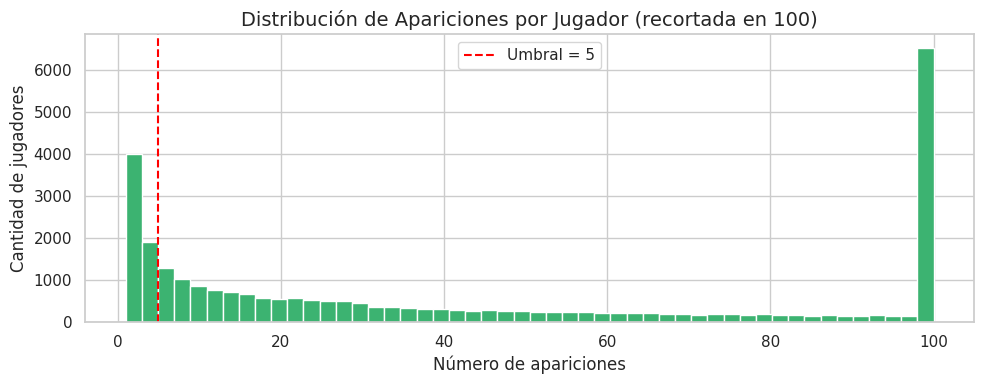

In [ ]:
# Filtrado: retener solo jugadores con apariciones suficientes
MIN_APARICIONES = 5  # umbral mínimo para que las estadísticas sean representativas

apariciones_por_jugador = appearances.groupby('player_id').size().reset_index(name='n_apariciones')

jugadores_activos = apariciones_por_jugador[apariciones_por_jugador['n_apariciones'] >= MIN_APARICIONES]
print(f'Jugadores con >= {MIN_APARICIONES} apariciones: {len(jugadores_activos):,} '
      f'({len(jugadores_activos)/apariciones_por_jugador.shape[0]*100:.1f}% del total)')

# Dataset filtrado para modelado
players_filtrado = players[players['player_id'].isin(jugadores_activos['player_id'])].copy()
print(f'Jugadores en dataset final: {len(players_filtrado):,}')

# Distribución de apariciones
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(apariciones_por_jugador['n_apariciones'].clip(upper=100), bins=50, color='mediumseagreen', edgecolor='white')
ax.axvline(MIN_APARICIONES, color='red', linestyle='--', linewidth=1.5, label=f'Umbral = {MIN_APARICIONES}')
ax.set_title('Distribución de Apariciones por Jugador (recortada en 100)')
ax.set_xlabel('Número de apariciones')
ax.set_ylabel('Cantidad de jugadores')
ax.legend()
plt.tight_layout()
plt.show()

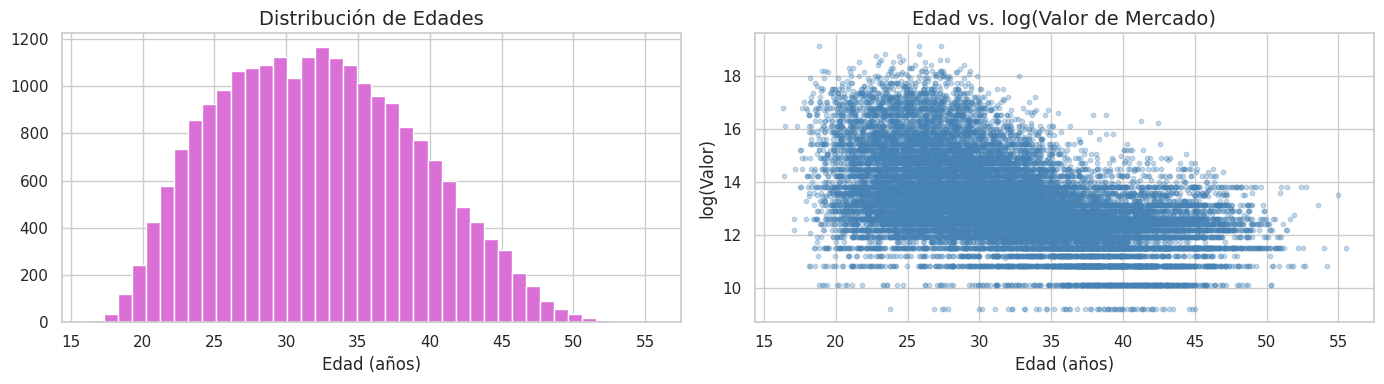

Edad promedio en dataset filtrado: 32.2 años


In [ ]:
# Feature adicional: edad del jugador
if 'date_of_birth' in players_filtrado.columns:
    players_filtrado['date_of_birth'] = pd.to_datetime(players_filtrado['date_of_birth'], errors='coerce')
    players_filtrado['edad'] = (
        pd.Timestamp('today') - players_filtrado['date_of_birth']
    ).dt.days / 365.25

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(players_filtrado['edad'].dropna(), bins=40, color='orchid', edgecolor='white')
    axes[0].set_title('Distribución de Edades')
    axes[0].set_xlabel('Edad (años)')

    axes[1].scatter(
        players_filtrado['edad'],
        players_filtrado['log_market_value'],
        alpha=0.3, s=10, color='steelblue'
    )
    axes[1].set_title('Edad vs. log(Valor de Mercado)')
    axes[1].set_xlabel('Edad (años)')
    axes[1].set_ylabel('log(Valor)')

    plt.tight_layout()
    plt.show()

    print(f'Edad promedio en dataset filtrado: {players_filtrado["edad"].mean():.1f} años')
else:
    print('Columna date_of_birth no encontrada en players.')

## 8. Feature Engineering — Variables Adicionales

En esta sección construimos cuatro variables derivadas que capturan información
contextual y temporal no disponible directamente en `players.csv`.
Cada feature se construye desde cero a partir de los CSVs originales.

| Variable | Fuente | Tipo | Descripción breve |
|---|---|---|---|
| `flag_club_grande` | `players.csv` + `competitions.csv` | Binaria (0/1) | Jugador en las 5 grandes ligas europeas |
| `tendencia_valor` | `player_valuations.csv` | Numérica (pendiente) | Dirección del valor en las últimas 3 valuaciones |
| `valor_mediano_liga` | `player_valuations.csv` | Numérica (euros) | Contexto económico de la liga del jugador |
| `indice_inflacion_mercado` | `player_valuations.csv` | Numérica (ratio) | Inflación global del mercado relativa al año 2020 |

### Carga de tabla auxiliar: competitions

In [ ]:
competitions = pd.read_csv(DATA_PATH + 'competitions.csv')
print(f'competitions: {competitions.shape}')
display(competitions[['competition_id','name','country_name','domestic_league_code']].head(10))

competitions: (67, 11)


,competition_id,name,country_name,domestic_league_code
0,A1,bundesliga,Austria,A1
1,AFAC,afc-asian-cup,NaN,NaN
2,AFCN,africa-cup-of-nations,NaN,NaN
3,ARG1,torneo-apertura,Argentina,ARG1
4,AUS1,a-league-men,Australia,AUS1
5,BE1,jupiler-pro-league,Belgium,BE1
6,BESC,volkswagen-supercup,Belgium,BE1
7,BRA1,campeonato-brasileiro-serie-a,Brazil,BRA1
8,C1,super-league,Switzerland,C1
9,CDR,copa-del-rey,Spain,ES1


---
### 8.1 `flag_club_grande` — Pertenencia a las 5 Grandes Ligas Europeas

**Construcción:** variable binaria que vale `1` si el jugador milita actualmente
en alguna de las cinco ligas más relevantes de Europa según su `competition_id`:

| Código | Liga |
|---|---|
| `GB1` | Premier League (Inglaterra) |
| `ES1` | La Liga (España) |
| `L1` | Bundesliga (Alemania) |
| `IT1` | Serie A (Italia) |
| `FR1` | Ligue 1 (Francia) |

In [ ]:
GRANDES_LIGAS = {'GB1', 'ES1', 'L1', 'IT1', 'FR1'}

# current_club_domestic_competition_id ya existe en players
players_filtrado['flag_club_grande'] = (
    players_filtrado['current_club_domestic_competition_id']
    .isin(GRANDES_LIGAS)
    .astype(int)
)

# Resumen con nombres de liga desde competitions
resumen_flag = (
    players_filtrado
    .groupby('flag_club_grande')
    .agg(
        n_jugadores=('player_id', 'count'),
        mediana_valor=('market_value_in_eur', 'median'),
        media_valor=('market_value_in_eur', 'mean')
    )
)
print(f'Jugadores en grandes ligas:  {players_filtrado["flag_club_grande"].sum():,}')
print(f'Jugadores en otras ligas:    {(players_filtrado["flag_club_grande"]==0).sum():,}')
display(resumen_flag)

Jugadores en grandes ligas:  6,481
Jugadores en otras ligas:    16,279


,n_jugadores,mediana_valor,media_valor
flag_club_grande,,,
0,16279,300000.0,1.039652e+06
1,6481,900000.0,5.653687e+06


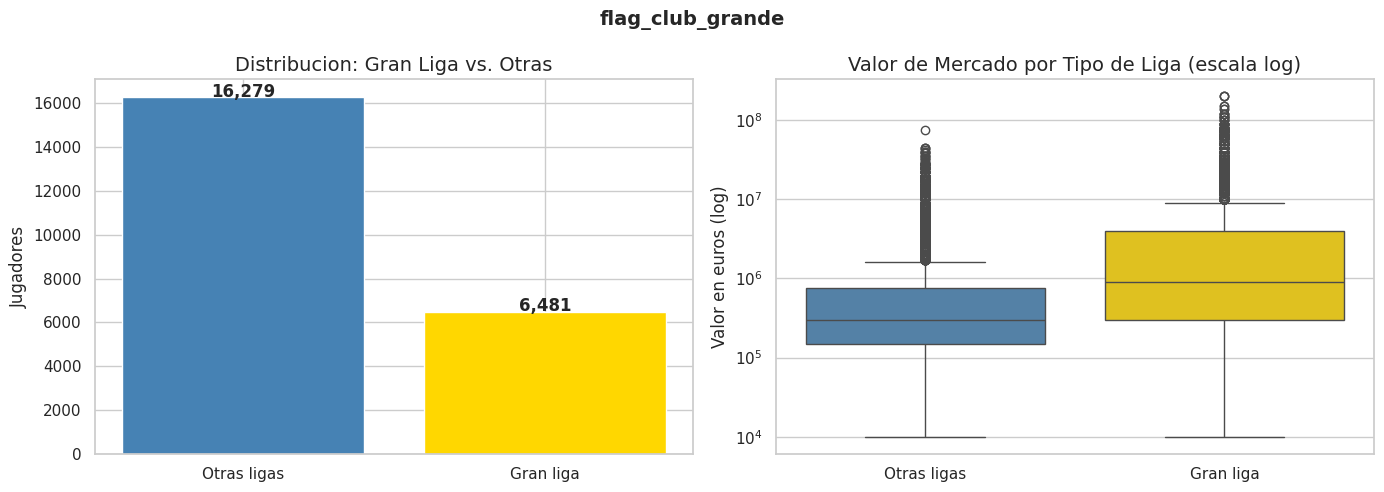

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo por tipo de liga
counts = players_filtrado['flag_club_grande'].value_counts().sort_index()
labels = ['Otras ligas', 'Gran liga']
colors = ['steelblue', 'gold']
axes[0].bar(labels, counts.values, color=colors, edgecolor='white')
axes[0].set_title('Distribucion: Gran Liga vs. Otras')
axes[0].set_ylabel('Jugadores')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

# Boxplot valor por flag
df_flag = players_filtrado[['flag_club_grande','market_value_in_eur']].dropna().copy()
df_flag['liga'] = df_flag['flag_club_grande'].map({0:'Otras ligas', 1:'Gran liga'})
sns.boxplot(data=df_flag, x='liga', y='market_value_in_eur',
            order=['Otras ligas','Gran liga'],
            palette={'Gran liga':'gold','Otras ligas':'steelblue'}, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Valor de Mercado por Tipo de Liga (escala log)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Valor en euros (log)')

plt.suptitle('flag_club_grande', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretacion para el modelo:**  
Los jugadores de las 5 grandes ligas tienden a tener valores de mercado
significativamente mas altos que los del resto, tanto en mediana como en
dispersion. Esta variable actua como proxy del nivel competitivo y la
exposicion mediatica del jugador. Se espera que sea una de las features de
mayor peso en modelos basados en arboles. Al ser binaria, no requiere
escalado y es trivialmente interpretable.

---
### 8.2 `tendencia_valor` — Pendiente de las Ultimas 3 Valuaciones

**Construccion:** para cada jugador se toman sus ultimas 3 entradas en
`player_valuations.csv` ordenadas por fecha. Se ajusta una regresion lineal
simple (`market_value ~ tiempo`) y se extrae la **pendiente** (euros/dia).

- Valor **positivo**: tendencia alcista (jugador en alza)
- Valor **negativo**: tendencia bajista
- `NaN`: menos de 2 registros disponibles

In [ ]:
valuations['date'] = pd.to_datetime(valuations['date'])
valuations['date_ord'] = valuations['date'].map(pd.Timestamp.toordinal)

def calcular_pendiente(grupo):
    ult = grupo.sort_values('date').tail(3)
    if len(ult) < 2:
        return np.nan
    x = ult['date_ord'].values.astype(float)
    y = ult['market_value_in_eur'].values.astype(float)
    coefs = np.polyfit(x - x.mean(), y, 1)
    return coefs[0]  # pendiente en euros/dia

print('Calculando tendencias...')
tendencias = (
    valuations.groupby('player_id')
    .apply(calcular_pendiente)
    .reset_index()
    .rename(columns={0: 'tendencia_valor'})
)

players_filtrado = players_filtrado.merge(tendencias, on='player_id', how='left')

cobertura = players_filtrado['tendencia_valor'].notna().sum()
print(f'Jugadores con tendencia calculada: {cobertura:,} / {len(players_filtrado):,}')
display(players_filtrado['tendencia_valor'].describe())

Calculando tendencias...
Jugadores con tendencia calculada: 22,461 / 22,760


,tendencia_valor
count,2.246100e+04
mean,3.045732e+02
std,1.208564e+04
min,-2.736144e+05
25%,-7.136620e+02
50%,-1.773820e+02
75%,4.242829e-13
max,3.490586e+05


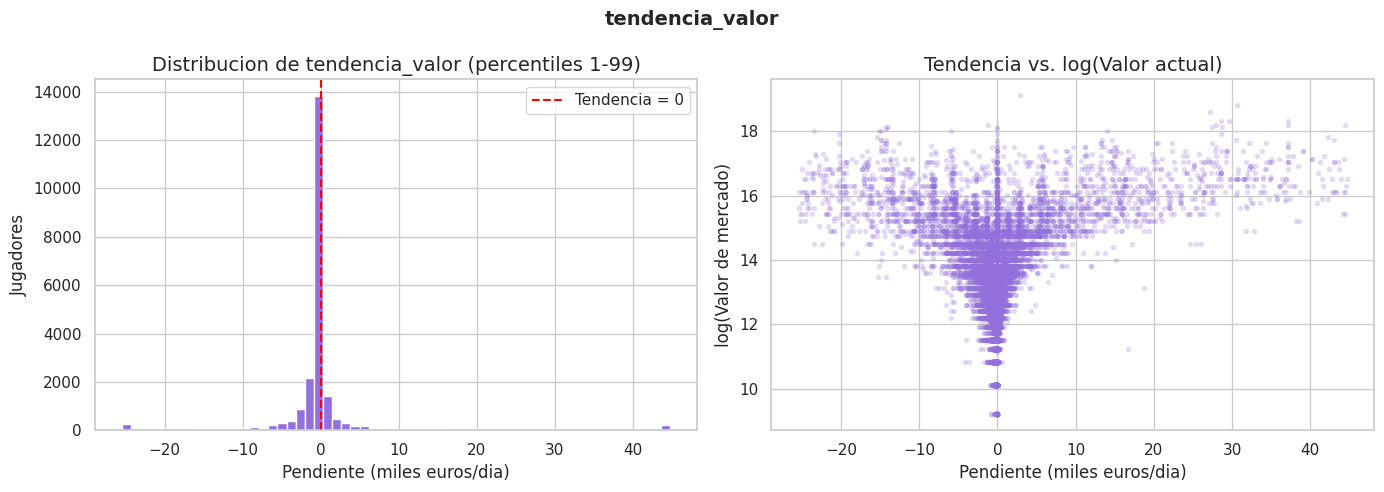

Jugadores con tendencia positiva (en alza): 28.6%
Jugadores con tendencia negativa: 71.4%


In [ ]:
p1, p99 = players_filtrado['tendencia_valor'].quantile([0.01, 0.99])
tv_clip = players_filtrado['tendencia_valor'].clip(p1, p99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(tv_clip.dropna() / 1000, bins=60, color='mediumpurple', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Tendencia = 0')
axes[0].set_title('Distribucion de tendencia_valor (percentiles 1-99)')
axes[0].set_xlabel('Pendiente (miles euros/dia)')
axes[0].set_ylabel('Jugadores')
axes[0].legend()

df_sc = players_filtrado[['tendencia_valor','log_market_value']].dropna()
df_sc = df_sc[df_sc['tendencia_valor'].between(p1, p99)]
axes[1].scatter(df_sc['tendencia_valor'] / 1000, df_sc['log_market_value'],
                alpha=0.2, s=8, color='mediumpurple')
axes[1].set_title('Tendencia vs. log(Valor actual)')
axes[1].set_xlabel('Pendiente (miles euros/dia)')
axes[1].set_ylabel('log(Valor de mercado)')

plt.suptitle('tendencia_valor', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

pct_alza = (players_filtrado['tendencia_valor'] > 0).sum() / players_filtrado['tendencia_valor'].notna().sum() * 100
print(f'Jugadores con tendencia positiva (en alza): {pct_alza:.1f}%')
print(f'Jugadores con tendencia negativa: {100 - pct_alza:.1f}%')

**Interpretacion para el modelo:**  
La tendencia reciente captura el *momentum* del jugador, una senal que los
modelos estaticos basados en el valor puntual no pueden detectar. Un jugador
con tendencia positiva fuerte suele ser joven y en desarrollo; uno con tendencia
negativa suele estar en declive o con lesiones frecuentes.
La pendiente es sensible a escalas; se recomienda normalizar (StandardScaler)
o convertirla en variable categorica (alza/estable/baja) para modelos lineales.

---
### 8.3 `valor_mediano_liga` — Contexto Economico de la Liga (por ano)

**Construccion:** usando `player_valuations.csv` y la columna
`player_club_domestic_competition_id`, se calcula el **valor mediano**
de todos los jugadores de cada liga para cada ano. Luego se hace un join
con `players_filtrado` usando la liga y el ano de la ultima valuacion disponible.

Esta variable actua como **variable contextual de grupo**: permite al modelo
distinguir si un jugador es caro o barato *relativo a su liga*.

In [ ]:
if 'year' not in valuations.columns:
    valuations['year'] = valuations['date'].dt.year

# Mediana de valor por (liga, ano)
mediana_liga_anio = (
    valuations
    .dropna(subset=['player_club_domestic_competition_id', 'market_value_in_eur'])
    .groupby(['player_club_domestic_competition_id', 'year'])['market_value_in_eur']
    .median()
    .reset_index()
    .rename(columns={
        'market_value_in_eur': 'valor_mediano_liga',
        'player_club_domestic_competition_id': 'comp_id_val'
    })
)

print(f'Combinaciones (liga, ano): {len(mediana_liga_anio):,}')
display(mediana_liga_anio.sort_values('valor_mediano_liga', ascending=False).head(10))

# Ultima valuacion por jugador: liga + ano
ultima_val = (
    valuations.sort_values('date')
    .groupby('player_id')
    .last()
    .reset_index()[['player_id', 'player_club_domestic_competition_id', 'year']]
    .rename(columns={'player_club_domestic_competition_id': 'liga_ultima_val',
                     'year': 'anio_ultima_val'})
)

players_filtrado = players_filtrado.merge(ultima_val, on='player_id', how='left')
players_filtrado = players_filtrado.merge(
    mediana_liga_anio,
    left_on=['liga_ultima_val', 'anio_ultima_val'],
    right_on=['comp_id_val', 'year'],
    how='left'
).drop(columns=['comp_id_val', 'year'], errors='ignore')

cobertura_liga = players_filtrado['valor_mediano_liga'].notna().sum()
print(f'Jugadores con valor_mediano_liga: {cobertura_liga:,} / {len(players_filtrado):,}')
display(players_filtrado['valor_mediano_liga'].describe())

Combinaciones (liga, ano): 700


,comp_id_val,year,valor_mediano_liga
241,GB1,2026,22000000.0
240,GB1,2025,15000000.0
239,GB1,2024,12000000.0
287,IT1,2026,10000000.0
131,COL1,2008,10000000.0
217,FR1,2026,7000000.0
374,MLS1,2006,7000000.0
350,L1,2026,7000000.0
194,ES1,2026,6000000.0
375,MLS1,2007,6000000.0


Jugadores con valor_mediano_liga: 22,239 / 22,760


,valor_mediano_liga
count,2.223900e+04
mean,1.722572e+06
std,3.264980e+06
min,2.000000e+05
25%,3.500000e+05
50%,6.000000e+05
75%,1.200000e+06
max,2.200000e+07


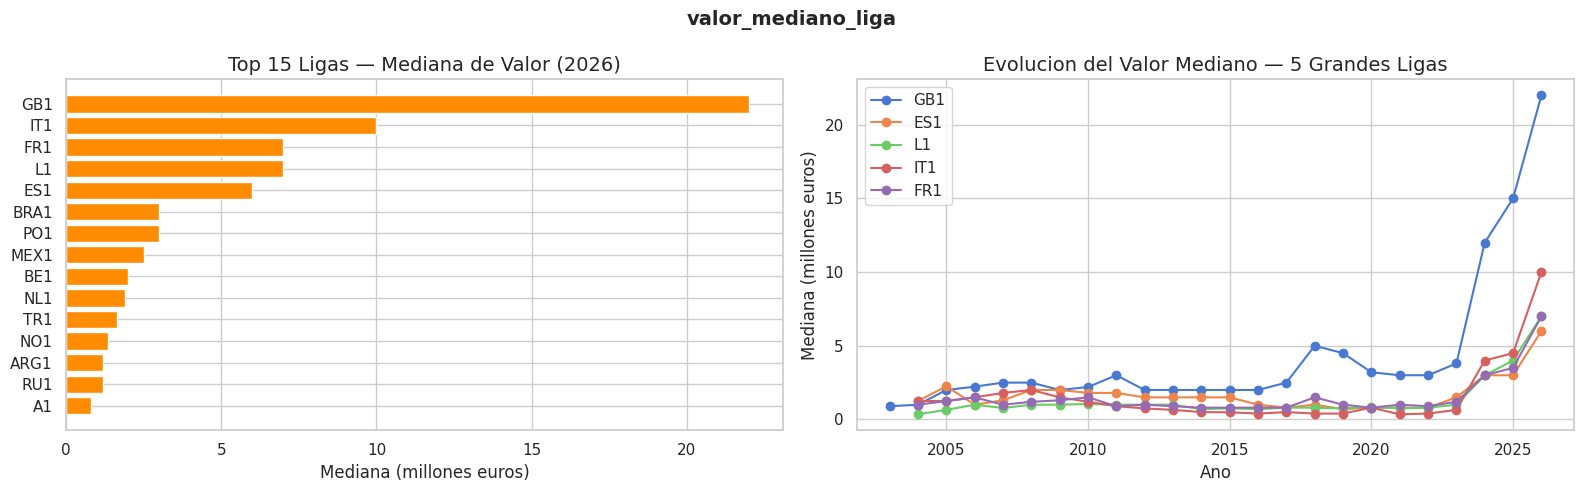

Correlacion Pearson (valor individual vs. mediana de liga): r = 0.517


In [ ]:
anio_max = mediana_liga_anio['year'].max()
top_ligas_df = (
    mediana_liga_anio[mediana_liga_anio['year'] == anio_max]
    .sort_values('valor_mediano_liga', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot horizontal top ligas
axes[0].barh(
    top_ligas_df['comp_id_val'][::-1],
    top_ligas_df['valor_mediano_liga'][::-1] / 1e6,
    color='darkorange', edgecolor='white'
)
axes[0].set_title(f'Top 15 Ligas — Mediana de Valor ({anio_max})')
axes[0].set_xlabel('Mediana (millones euros)')

# Evolucion de las 5 grandes
for liga in ['GB1', 'ES1', 'L1', 'IT1', 'FR1']:
    datos = mediana_liga_anio[mediana_liga_anio['comp_id_val'] == liga]
    if not datos.empty:
        axes[1].plot(datos['year'], datos['valor_mediano_liga'] / 1e6,
                     marker='o', label=liga)
axes[1].set_title('Evolucion del Valor Mediano — 5 Grandes Ligas')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Mediana (millones euros)')
axes[1].legend()

plt.suptitle('valor_mediano_liga', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

corr = players_filtrado[['market_value_in_eur','valor_mediano_liga']].dropna().corr().iloc[0,1]
print(f'Correlacion Pearson (valor individual vs. mediana de liga): r = {corr:.3f}')

**Interpretacion para el modelo:**  
El valor mediano de la liga captura el *nivel economico del entorno* del jugador.
Un mismo nivel de rendimiento puede traducirse en valores muy diferentes segun
si el jugador juega en la Premier League o en una liga menor.
Al incluir esta variable, el modelo puede aprender relatividades: un jugador
que vale el doble que la mediana de su liga es mas destacado que uno que vale
el doble en una liga con poca competencia. La correlacion positiva con el
valor individual confirma su poder predictivo.

---
### 8.4 `indice_inflacion_mercado` — Indice de Inflacion Global del Mercado

**Construccion:**
1. Se calcula el valor mediano global de todos los jugadores para cada ano.
2. Se normaliza usando el ano **2020** como base = 1.0.
3. Se asigna el indice correspondiente a cada jugador segun el ano
   de su ultima valuacion disponible.

Un indice > 1 indica que el mercado global en ese ano estaba inflado
respecto a 2020; < 1 que estaba deflacionado (ej. pandemia, crisis).

In [ ]:
if 'year' not in valuations.columns:
    valuations['year'] = valuations['date'].dt.year

# Mediana global por ano
mediana_global = (
    valuations.dropna(subset=['market_value_in_eur'])
    .groupby('year')['market_value_in_eur']
    .median()
    .reset_index()
    .rename(columns={'market_value_in_eur': 'mediana_global'})
)

# Base 2020; fallback al ano mas cercano si no existe
if 2020 in mediana_global['year'].values:
    base = mediana_global.loc[mediana_global['year'] == 2020, 'mediana_global'].iloc[0]
else:
    idx_cercano = (mediana_global['year'] - 2020).abs().idxmin()
    base = mediana_global.loc[idx_cercano, 'mediana_global']
    print(f'Ano 2020 no disponible; usando fallback con base = {base:.0f} euros')

mediana_global['indice_inflacion_mercado'] = mediana_global['mediana_global'] / base
print('Indice de inflacion de mercado por ano (base 2020 = 1.0):')
display(mediana_global)

# Join con players_filtrado usando anio_ultima_val
players_filtrado = players_filtrado.merge(
    mediana_global[['year', 'indice_inflacion_mercado']],
    left_on='anio_ultima_val',
    right_on='year',
    how='left'
).drop(columns=['year'], errors='ignore')

cob_idx = players_filtrado['indice_inflacion_mercado'].notna().sum()
print(f'Jugadores con indice asignado: {cob_idx:,} / {len(players_filtrado):,}')
display(players_filtrado['indice_inflacion_mercado'].describe())

Indice de inflacion de mercado por ano (base 2020 = 1.0):


,year,mediana_global,indice_inflacion_mercado
0,2000,150000.0,0.315789
1,2001,100000.0,0.210526
2,2003,650000.0,1.368421
3,2004,600000.0,1.263158
4,2005,850000.0,1.789474
5,2006,800000.0,1.684211
6,2007,850000.0,1.789474
7,2008,850000.0,1.789474
8,2009,800000.0,1.684211
9,2010,750000.0,1.578947


Jugadores con indice asignado: 22,529 / 22,760


,indice_inflacion_mercado
count,22529.000000
mean,1.297411
std,0.483336
min,0.842105
25%,0.947368
50%,1.052632
75%,1.473684
max,2.526316


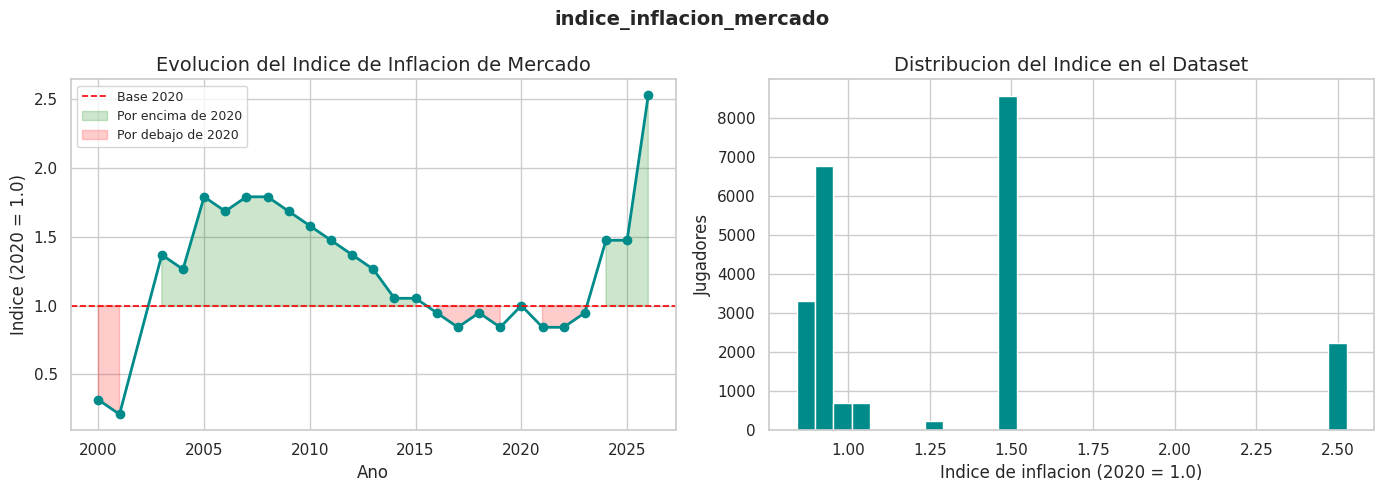

Indice por ano en el dataset:


,anio_ultima_val,indice_inflacion_mercado
0,2010.0,1.578947
1,2011.0,1.473684
2,2012.0,1.368421
3,2013.0,1.263158
4,2014.0,1.052632
5,2015.0,1.052632
6,2016.0,0.947368
7,2017.0,0.842105
8,2018.0,0.947368
9,2019.0,0.842105


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Evolucion del indice
axes[0].plot(mediana_global['year'], mediana_global['indice_inflacion_mercado'],
             marker='o', color='darkcyan', linewidth=2)
axes[0].axhline(1.0, color='red', linestyle='--', linewidth=1.2, label='Base 2020')
axes[0].fill_between(
    mediana_global['year'], mediana_global['indice_inflacion_mercado'], 1.0,
    where=(mediana_global['indice_inflacion_mercado'] >= 1.0),
    alpha=0.2, color='green', label='Por encima de 2020'
)
axes[0].fill_between(
    mediana_global['year'], mediana_global['indice_inflacion_mercado'], 1.0,
    where=(mediana_global['indice_inflacion_mercado'] < 1.0),
    alpha=0.2, color='red', label='Por debajo de 2020'
)
axes[0].set_title('Evolucion del Indice de Inflacion de Mercado')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Indice (2020 = 1.0)')
axes[0].legend(fontsize=9)

# Distribucion del indice asignado
axes[1].hist(players_filtrado['indice_inflacion_mercado'].dropna(),
             bins=30, color='darkcyan', edgecolor='white')
axes[1].set_title('Distribucion del Indice en el Dataset')
axes[1].set_xlabel('Indice de inflacion (2020 = 1.0)')
axes[1].set_ylabel('Jugadores')

plt.suptitle('indice_inflacion_mercado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Indice por ano en el dataset:')
display(
    players_filtrado.groupby('anio_ultima_val')['indice_inflacion_mercado']
    .first().reset_index().sort_values('anio_ultima_val')
)

**Interpretacion para el modelo:**  
El mercado de futbol no es estatico: los valores globales crecieron sostenidamente
hasta 2020 y sufrieron una caida notoria por la pandemia de COVID-19.
Sin este ajuste, comparar el valor de un jugador en 2016 con uno en 2023 introduce
un sesgo sistematico. Al incluir el indice, el modelo puede descontar la inflacion
del mercado y enfocarse en senales individuales. Esta variable es especialmente
util si se entrena con datos historicos de multiples anos.

---
### Resumen: Dataset con las 4 Nuevas Variables

In [ ]:
features_nuevas = ['flag_club_grande', 'tendencia_valor',
                   'valor_mediano_liga', 'indice_inflacion_mercado']

print(f'Estado final de players_filtrado:')
print(f'  Filas:    {len(players_filtrado):,}')
print(f'  Columnas: {players_filtrado.shape[1]}')
print()
print('Cobertura de las nuevas features:')
for feat in features_nuevas:
    if feat in players_filtrado.columns:
        pct = players_filtrado[feat].notna().mean() * 100
        print(f'  {feat}: {pct:.1f}% no-nulo')
    else:
        print(f'  {feat}: NO ENCONTRADA')

print()
print('Correlaciones con log_market_value:')
corr_cols = [c for c in features_nuevas if c in players_filtrado.columns] + ['log_market_value']
display(
    players_filtrado[corr_cols].corr()[['log_market_value']]
    .drop('log_market_value')
    .sort_values('log_market_value', ascending=False)
)

Estado final de players_filtrado:
  Filas:    22,760
  Columnas: 35

Cobertura de las nuevas features:
  flag_club_grande: 100.0% no-nulo
  tendencia_valor: 98.7% no-nulo
  valor_mediano_liga: 97.7% no-nulo
  indice_inflacion_mercado: 99.0% no-nulo

Correlaciones con log_market_value:


,log_market_value
indice_inflacion_mercado,0.577432
valor_mediano_liga,0.544285
flag_club_grande,0.335086
tendencia_valor,0.137629


## 9. Reflexión Final

### Decisiones tomadas

**Transformación logarítmica del target:**  
El valor de mercado tiene una distribución fuertemente sesgada (jugadores de élite con valores extremos). Aplicar `log1p` acerca la distribución a la normalidad, lo que beneficia a modelos lineales y reduce la influencia de outliers en el entrenamiento.

**Filtrado por apariciones mínimas:**  
Jugadores con muy pocas apariciones tienen estadísticas poco representativas. Se eligió un umbral de 5 apariciones como mínimo razonable para conservar una muestra amplia sin incorporar ruido.

**Encoding de posición:**  
Se optó por un encoding ordinal (portero → defensor → mediocampista → delantero) como primera aproximación. En la etapa de modelado se evaluará también one-hot encoding para modelos no lineales como árboles.

**Feature de edad:**  
La edad tiene una relación no lineal con el valor de mercado (sube hasta los ~24-27 años y luego cae). Esto puede requerir transformaciones adicionales (polinomios, bins) en la etapa de feature engineering.

---

### Dificultades encontradas

- **Valores faltantes en columnas clave** como `market_value_in_eur`: requieren estrategias de imputación cuidadosas ya que el dato faltante puede no ser aleatorio (jugadores menos conocidos tienen menos datos).
- **Cobertura temporal desigual**: hay más registros de valuación en años recientes, lo que puede introducir sesgo si no se maneja correctamente.
- **Outliers legítimos**: los valores extremos de jugadores como Mbappé o Haaland son reales, no errores. No deben eliminarse sino tratarse con la transformación log.
- **Granularidad del dataset**: la tabla `appearances` tiene millones de filas; las agregaciones requieren atención al rendimiento computacional.

---

### Próximos pasos

1. **Feature Engineering:** agregar estadísticas por jugador desde `appearances` (goles/partido, asistencias, minutos promedio), historial de transferencias desde `transfers`, y contexto del club/liga.
2. **Split temporal:** dividir entrenamiento y evaluación por fechas para evitar data leakage (usar valuaciones históricas para predecir el valor futuro).
3. **Modelado:** evaluar modelos baseline (Regresión Lineal, Ridge) y modelos más complejos (Random Forest, XGBoost, LightGBM).
4. **Interpretabilidad:** usar SHAP values para entender qué variables explican mejor el valor de mercado.
5. **Validación:** métricas principales serán RMSE y MAE sobre la escala original (en euros), y R² sobre escala log.